# Learning-rate sensitivity at 100 labelled images

**Stage 3 scientific report.** This notebook compares three fixed learning rates for random and ImageNet initialization under the otherwise unchanged Stage 2 recipe. It also diagnoses threshold sensitivity for the two existing `3e-4` reference checkpoints. All analyses use saved artifacts; no cell starts training.

## 1. Research question and fixed comparison

The Stage 2 pilot found validation IoU 0.813 for random initialization and 0.862 for ImageNet initialization at 100 training images and learning rate `3e-4`. We ask whether either initialization is sensitive to learning rate, whether random initialization benefits from a different rate, and whether the pretraining advantage remains at matched rates.

The approved candidates are `1e-4`, `3e-4` and `1e-3`. The two `3e-4` runs are the verified Stage 2 references; the other four models start fresh. All six configurations use the same Seed 17 subset, model seed, data order, D4 augmentation sequence, architecture, normalization, objective, weight decay, BatchNorm policy and 2,000-update horizon. The 259 test images remain excluded from training, selection, threshold analysis and examples.

### Selection and interpretation

The primary metric remains equally weighted mean per-image validation intersection over union (IoU) at probability threshold 0.5. Each run selects its highest trained validation IoU, with the earlier step winning ties; step 0 is diagnostic only. We report both best and final-step IoU because a low learning rate may still be improving at the fixed horizon. Comparisons at matched learning rates are primary. Selecting the best observed rate separately for each initialization uses the same validation data and is therefore explicitly exploratory.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
RESULTS = pd.read_csv(ROOT / 'reports/optimization_learning_rate_results.csv')
THRESHOLDS = pd.read_csv(ROOT / 'reports/optimization_threshold_results.csv')

## 2. Selected-checkpoint results

The table includes the six configurations, their selected validation metrics, final-step IoU and measured runtime. Average precision (AP) is averaged over the 288 validation images containing roof pixels; the empty reference is excluded only from AP.

In [2]:
columns = {
    'initialization': 'initialization', 'learning_rate': 'learning rate',
    'best_validation_iou': 'best IoU', 'last_validation_iou': 'last IoU',
    'validation_dice': 'Dice', 'validation_ap': 'AP',
    'validation_ap_images': 'AP images', 'best_step': 'best step',
    'total_minutes': 'minutes',
}
display(RESULTS[list(columns)].rename(columns=columns).style.format({
    'learning rate': '{:.0e}', 'best IoU': '{:.3f}', 'last IoU': '{:.3f}',
    'Dice': '{:.3f}', 'AP': '{:.3f}', 'minutes': '{:.1f}',
}).hide(axis='index'))

initialization,learning rate,best IoU,last IoU,Dice,AP,AP images,best step,minutes
imagenet,1e-04,0.857,0.857,0.918,0.945,288,2000,12.9
imagenet,3e-04,0.862,0.858,0.923,0.960,288,1400,13.2
imagenet,1e-03,0.865,0.865,0.924,0.970,288,2000,13.1
random,1e-04,0.793,0.793,0.879,0.943,288,2000,13.4
random,3e-04,0.813,0.807,0.892,0.957,288,1700,13.1
random,1e-03,0.817,0.817,0.894,0.959,288,1800,13.2


At matched learning rates, ImageNet initialization has the higher selected IoU in all three comparisons. Random initialization improves from 0.793 at `1e-4` to 0.813 at `3e-4` and 0.817 at `1e-3`. ImageNet improves from 0.857 to 0.862 and 0.865. The best observed rate is therefore `1e-3` for both initializations, but this conclusion is selected on the same validation region and the margins over `3e-4` are small: 0.004 for random and 0.003 for ImageNet.

The four new runs required 42.2 minutes of optimization and 52.7 minutes including evaluation on MPS, closely matching the 53-minute estimate. All AP values average the same 288 non-empty validation images.

## 3. Learning trajectories and fixed horizon

The upper panels show validation IoU at every predeclared evaluation. The lower panels show the augmented training objective over the preceding 100 updates. The objective is useful for optimization diagnostics but is not directly comparable with unaugmented validation loss.

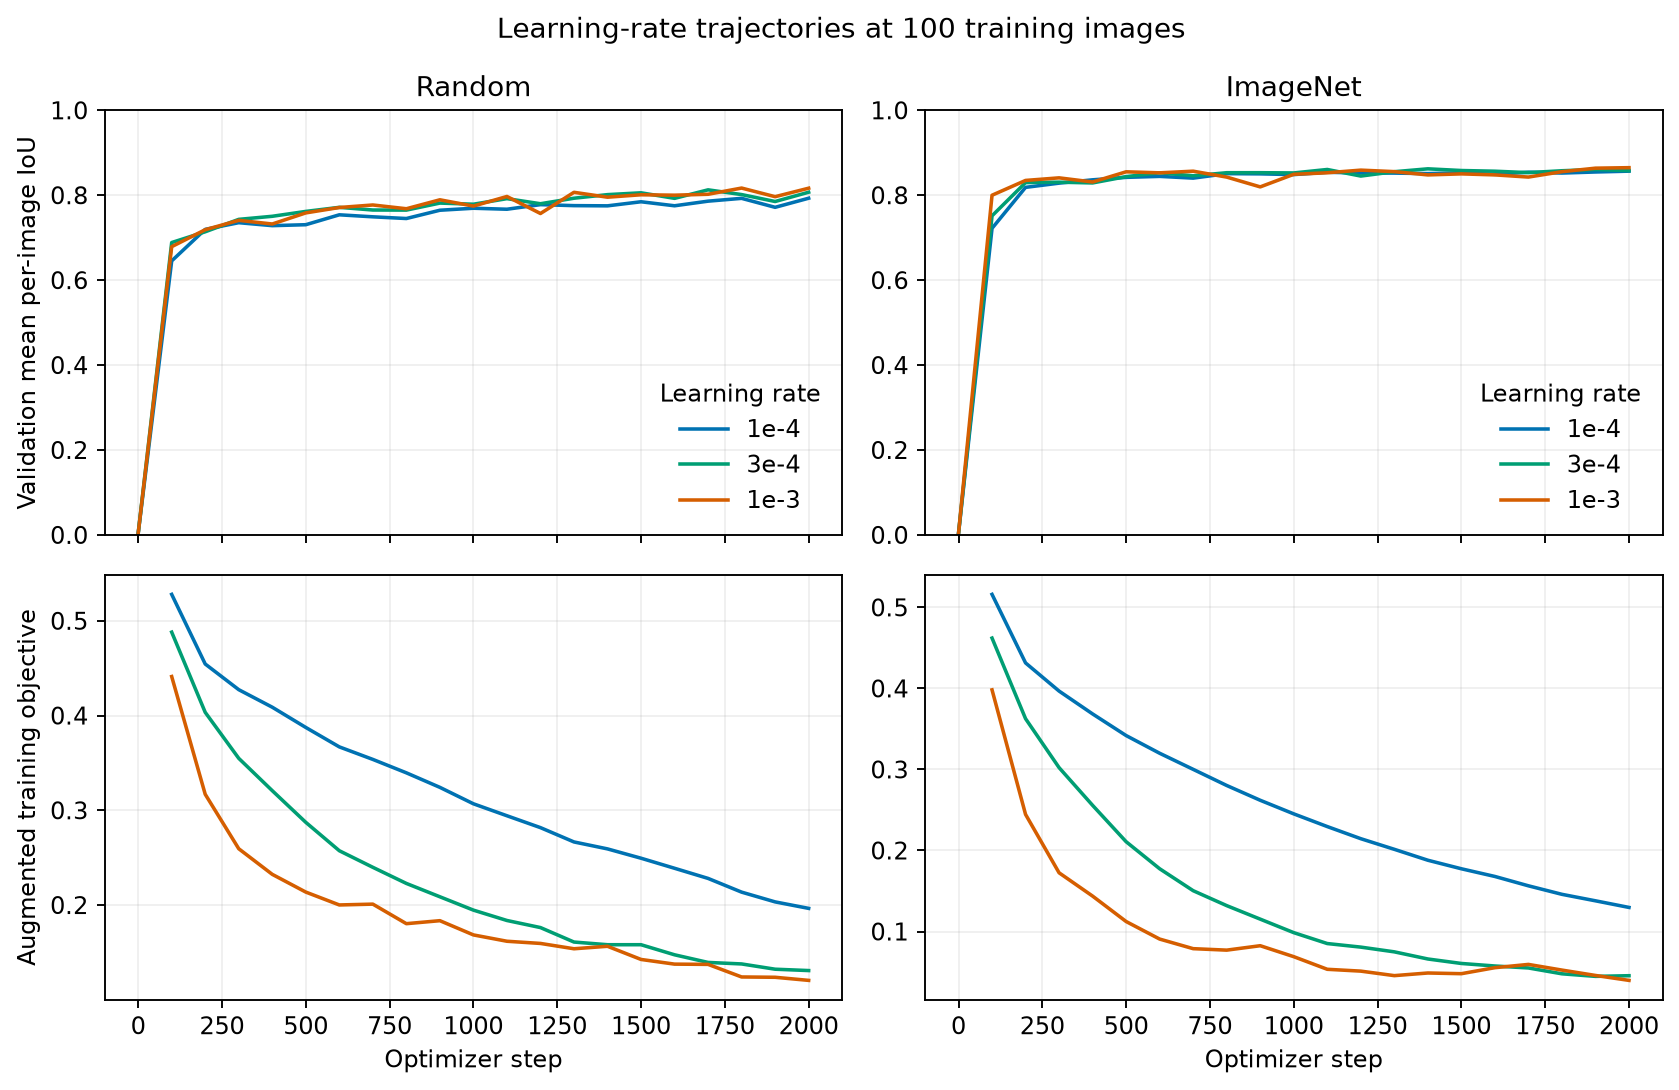

In [3]:
display(Image(filename=ROOT / 'reports/figures/optimization_learning_rate_curves.png'))

Both `1e-4` runs select the final step and their training objectives remain substantially above those at larger rates. Their lower 2,000-step scores therefore indicate underoptimization at this horizon rather than a demonstrated lower attainable performance. The `1e-3` random run selects step 1,800 and ends at nearly the same IoU; the ImageNet run is more variable but reaches its best result at step 2,000. None of these observations establishes convergence beyond the fixed horizon.

## 4. Matched-rate initialization differences

Within every rate, the two initializations use the same subset, data order, D4 codes and initial decoder. Positive values below mean that ImageNet initialization scores higher than random initialization at the corresponding selected checkpoints.

,IoU,Dice,AP
learning_rate,,,
0.000100,+0.064,+0.039,+0.002
0.000300,+0.050,+0.031,+0.003
0.001000,+0.048,+0.029,+0.011


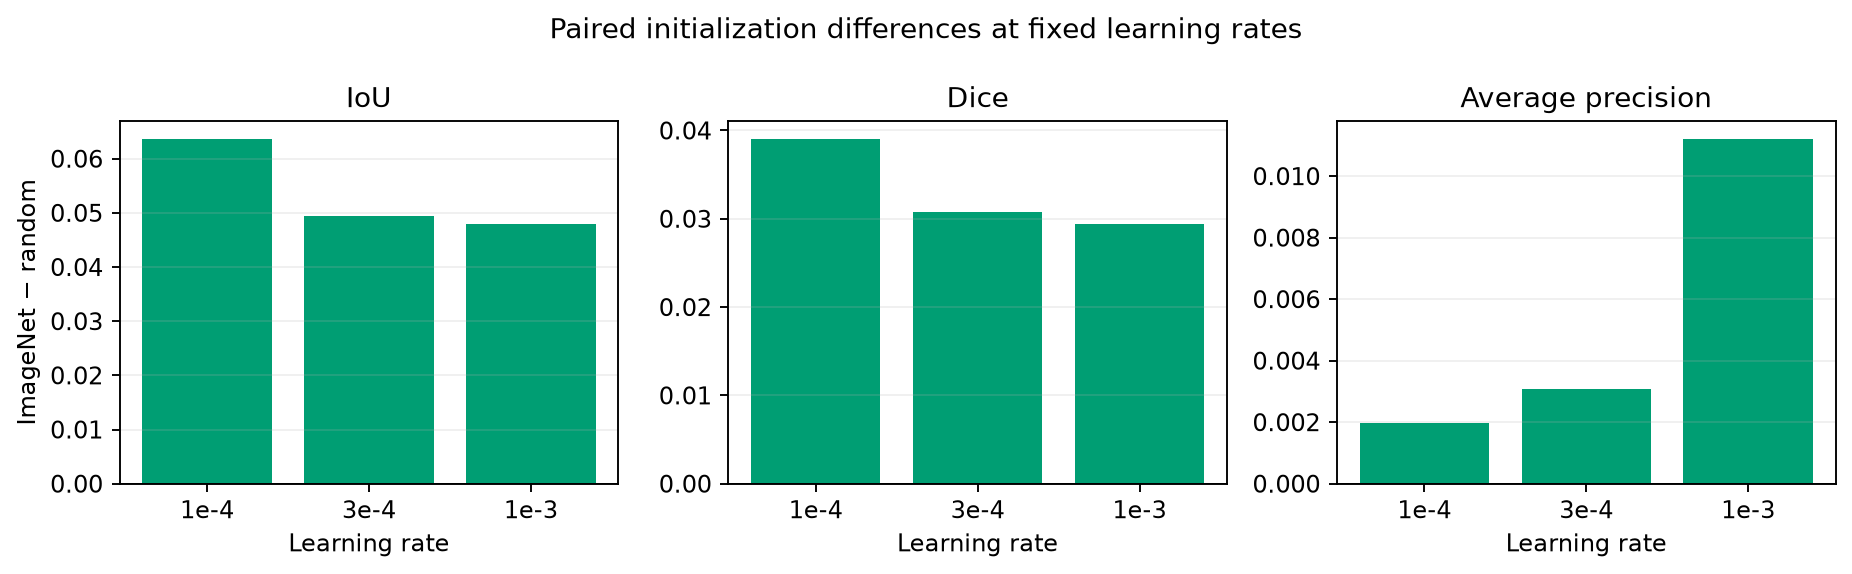

In [4]:
paired = RESULTS.pivot(index='learning_rate', columns='initialization',
                       values=['best_validation_iou', 'validation_dice', 'validation_ap'])
differences = pd.DataFrame({
    name: paired[(column, 'imagenet')] - paired[(column, 'random')]
    for name, column in {'IoU': 'best_validation_iou', 'Dice': 'validation_dice',
                         'AP': 'validation_ap'}.items()
})
display(differences.style.format('{:+.3f}'))
display(Image(filename=ROOT / 'reports/figures/optimization_paired_differences.png'))

The ImageNet-minus-random IoU differences are +0.064 at `1e-4`, +0.050 at `3e-4` and +0.048 at `1e-3`. The pretraining advantage therefore remains positive throughout the fixed search range and is not removed by giving random initialization the same higher rate. Dice shows the same ordering. AP differences are smaller at `1e-4` and `3e-4`, illustrating that similar pixel ranking does not imply the same thresholded overlap.

## 5. Diagnostic threshold sensitivity of the references

For exactly the two stored `3e-4` reference checkpoints, we recompute validation IoU at thresholds 0.1 through 0.9. Aggregation and empty-mask rules are unchanged. This diagnostic does not alter the primary threshold, checkpoint selection or learning-rate selection. A favourable validation threshold would not be an independently confirmed result, and similar AP does not establish equal segmentation quality or probability calibration.

initialization,imagenet,random
threshold,,
0.100000,0.853,0.783
0.200000,0.859,0.805
0.300000,0.861,0.811
0.400000,0.862,0.812
0.500000,0.862,0.813
0.600000,0.861,0.810
0.700000,0.858,0.806
0.800000,0.849,0.795
0.900000,0.813,0.754


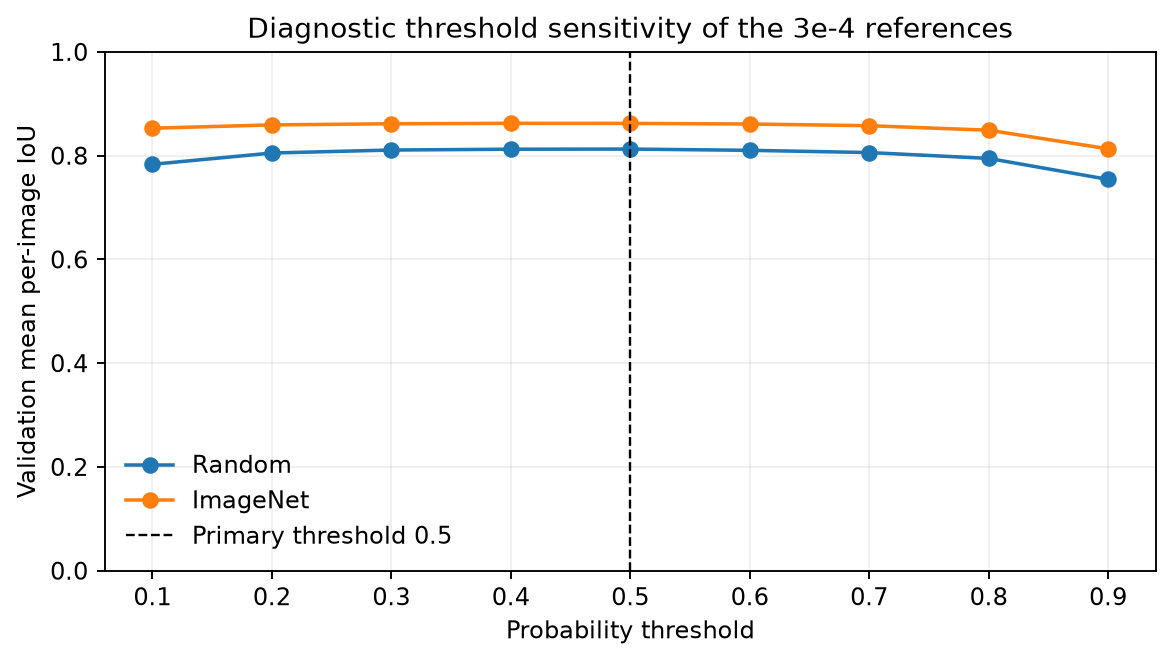

In [5]:
threshold_table = THRESHOLDS.pivot(index='threshold', columns='initialization', values='mean_iou')
display(threshold_table.style.format('{:.3f}'))
display(Image(filename=ROOT / 'reports/figures/optimization_threshold_curves.png'))

Random initialization reaches its maximum measured IoU at the primary threshold 0.5. ImageNet reaches 0.8623 at 0.4 versus 0.8622 at 0.5, a negligible validation-selected difference. Across all nine thresholds, ImageNet remains ahead by 0.050–0.070 IoU. The reference gap is therefore not explained by an unfortunate threshold choice for the random model, although this coarse diagnostic is not a calibration study.

## 6. Common validation cases

The examples compare each initialization at its best observed learning rate. Cases are selected from validation metrics to show a shared failure, the largest disagreement, a shared success and the known empty target; criteria may coincide. Error maps use green for true positives, orange for false positives and blue for false negatives. No test image or prediction is used.

Selected validation IDs: 39, 1252, 147


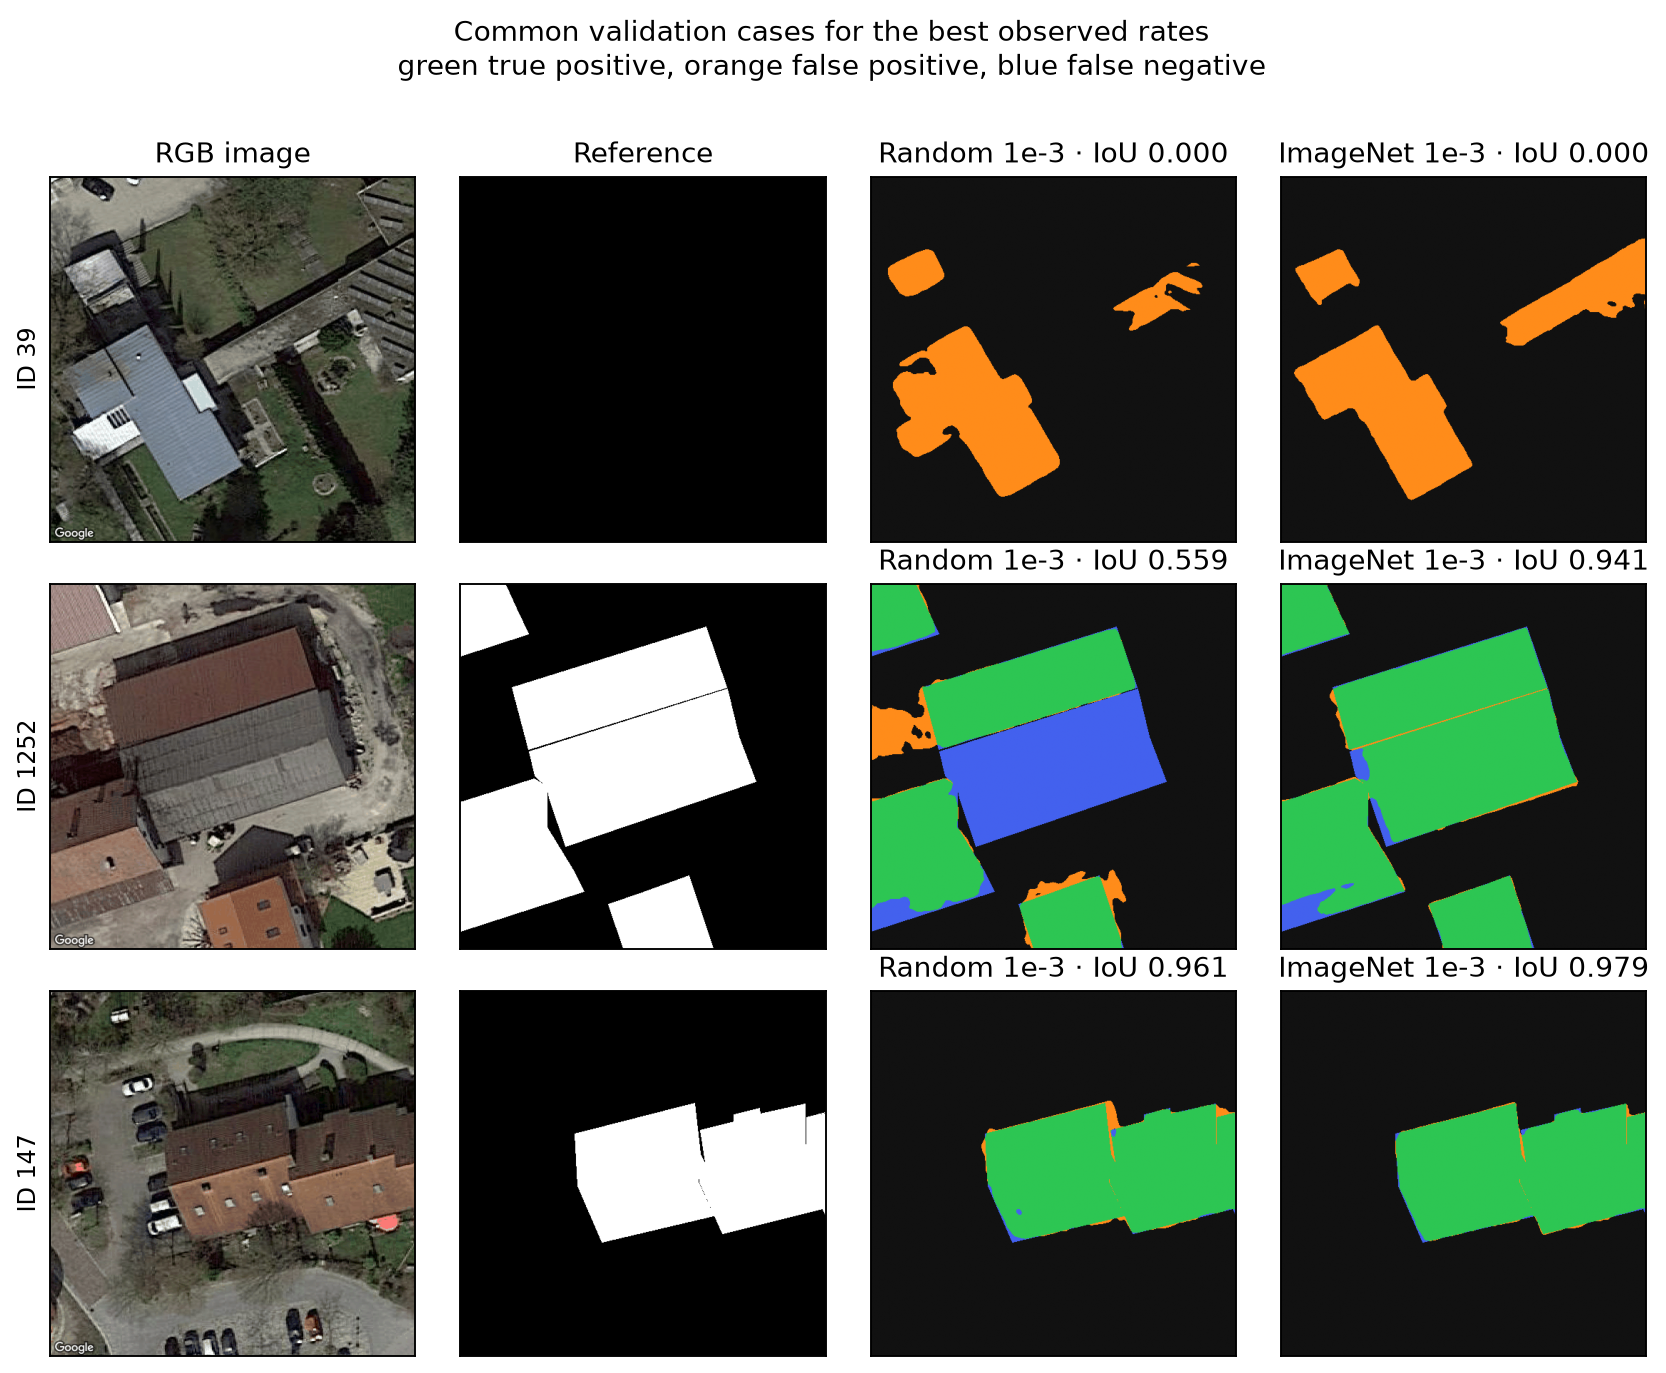

In [6]:
selected_ids = (ROOT / 'reports/optimization_example_ids.txt').read_text().splitlines()
print('Selected validation IDs:', ', '.join(selected_ids))
display(Image(filename=ROOT / 'reports/figures/optimization_examples.png'))

The four criteria yield three unique IDs because the empty target, ID 39, is also the lowest paired-IoU case; both models produce false positives and score IoU 0. ID 1252 is the largest disagreement between the two best-rate models: the ImageNet model recovers substantially more of the central roof. ID 147 is a shared high-IoU case. These validation-selected examples explain error structure but do not constitute independent evidence.

## 7. Limitations and next decision

Within this one-subset, 2,000-update search, `1e-3` gives the highest validation IoU for both initializations. ImageNet initialization remains ahead at every matched rate, with a +0.048 IoU difference at `1e-3`. The threshold diagnostic shows that the Stage 2 reference gap persists across the fixed 0.1–0.9 range.

The block does not measure subset-seed variation, separately confirmed hyperparameters or test performance. Best-rate comparisons and the qualitative examples are selected on the same validation region. The low-rate curves also show that equal updates do not provide equal optimization progress.

A limited next block should isolate training horizon before adding a scheduler or weight-decay search: rerun `1e-4` for both initializations from fresh states for 4,000 updates with every other setting unchanged. Two runs are estimated at about 50–55 minutes on the measured MPS setup. This would test whether the still-improving low-rate candidates close the gap under more updates; no such run is started here.